# Reproducing and Extending a Stacking Ensemble for Heart Disease Prediction
**HD Task – Machine Learning Mini Research**
Author: Khac Truong Kiet (TK) Tran  
Student ID: 224874982  
Date: 28/9/2026    

Reproduced paper: M. Bhagat, A. Sharma, and P. Agarwal, "An efficient stacking-based ensemble technique for early heart attack prediction," *Multimedia Tools and Applications*, vol. 84, pp. 36351–36375, 2025.

Dataset: Kaggle Heart Disease Dataset (johnsmith88), `heart.csv` in the same folder as this notebook.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split, RepeatedStratifiedKFold,
                                     StratifiedKFold, cross_validate)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, matthews_corrcoef, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)
from xgboost import XGBClassifier
from scipy.stats import wilcoxon, t

SEED = 42

## Part 1 – Data verification
Checks the dataset against the paper's description (Table 9): shape, missing values, class balance, duplicates and value ranges.

In [2]:
df = pd.read_csv("heart.csv")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nMissing values:", df.isnull().sum().sum())
print("\nClass distribution:\n", df["target"].value_counts())
print("\nDuplicate rows:", df.duplicated().sum())
print("Unique rows:", df.drop_duplicates().shape[0])
print("\nRanges:\n", df.describe().T[["min", "max"]])

Shape: (1025, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Missing values: 0

Class distribution:
 target
1    526
0    499
Name: count, dtype: int64

Duplicate rows: 723
Unique rows: 302

Ranges:
             min    max
age        29.0   77.0
sex         0.0    1.0
cp          0.0    3.0
trestbps   94.0  200.0
chol      126.0  564.0
fbs         0.0    1.0
restecg     0.0    2.0
thalach    71.0  202.0
exang       0.0    1.0
oldpeak     0.0    6.2
slope       0.0    2.0
ca          0.0    4.0
thal        0.0    3.0
target      0.0    1.0


In [3]:
#Codes outside the ranges given in Table 9 (missing values in the original UCI data)
print("ca == 4:", (df["ca"] == 4).sum())
print("thal == 0:", (df["thal"] == 0).sum())

ca == 4: 18
thal == 0: 7


## Part 1 – Reproduction of Table 11
Paper setup with stated assumptions: 80/20 random split (not stratified, inferred from the 205-record confusion matrices), StandardScaler fitted on training data, default hyperparameters, 5-fold stacking with a Logistic Regression meta-learner. AUC is computed from probabilities; hard-label AUC is also reported for comparison with the paper's ROC curves.

In [4]:
X, y = df.drop(columns="target"), df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print("Test class counts:", y_test.value_counts().sort_index().to_dict())

train_rows = set(map(tuple, df.loc[X_train.index].values))
overlap = sum(tuple(r) in train_rows for r in df.loc[X_test.index].values)
print(f"Test rows also in train: {overlap}/{len(X_test)}")

def base_models():
    return {
        "LR": LogisticRegression(),
        "DT": DecisionTreeClassifier(random_state=SEED),
        "RF": RandomForestClassifier(random_state=SEED),
        "XGB": XGBClassifier(random_state=SEED, eval_metric="logloss"),
        "NB": GaussianNB(),
        "KNN": KNeighborsClassifier(),
    }

models = {n: make_pipeline(StandardScaler(), m) for n, m in base_models().items()}
models["Stacking"] = make_pipeline(StandardScaler(), StackingClassifier(
    estimators=list(base_models().items()),
    final_estimator=LogisticRegression(), cv=5))

def evaluate(model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    return {
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
        "F1": f1_score(y_te, y_pred),
        "Specificity": tn / (tn + fp),
        "MCC": matthews_corrcoef(y_te, y_pred),
        "AUC": roc_auc_score(y_te, y_prob),
        "AUC (hard labels)": roc_auc_score(y_te, y_pred),
        "TN/FP/FN/TP": f"{tn}/{fp}/{fn}/{tp}",
    }

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = evaluate(model, X_test, y_test)

res_df = pd.DataFrame(results).T
res_df

Test class counts: {0: 102, 1: 103}
Test rows also in train: 199/205


,Accuracy,Precision,Recall,F1,Specificity,MCC,AUC,AUC (hard labels),TN/FP/FN/TP
LR,0.795122,0.756303,0.873786,0.810811,0.715686,0.597255,0.878736,0.794736,73/29/13/90
DT,0.985366,1.0,0.970874,0.985222,1.0,0.971151,0.985437,0.985437,102/0/3/100
RF,0.985366,1.0,0.970874,0.985222,1.0,0.971151,1.0,0.985437,102/0/3/100
XGB,0.985366,1.0,0.970874,0.985222,1.0,0.971151,0.989435,0.985437,102/0/3/100
NB,0.8,0.754098,0.893204,0.817778,0.705882,0.610224,0.87055,0.799543,72/30/11/92
KNN,0.834146,0.8,0.893204,0.844037,0.77451,0.672727,0.948553,0.833857,79/23/11/92
Stacking,0.985366,1.0,0.970874,0.985222,1.0,0.971151,1.0,0.985437,102/0/3/100


## Part 1 – Variation across 30 random splits
Repeats the paper setup over 30 split seeds (models unchanged) and compares mean ± std with Table 11 of the paper.

In [5]:
SEEDS = range(30)
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
order = ["LR", "DT", "RF", "XGB", "NB", "KNN", "Stacking"]

rows, overlaps = [], []
for s in SEEDS:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=s)
    tr = set(map(tuple, df.loc[X_tr.index].values))
    overlaps.append(sum(tuple(r) in tr for r in df.loc[X_te.index].values) / len(X_te))
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        r = evaluate(model, X_te, y_te)
        rows.append({"Seed": s, "Model": name, **{m: r[m] for m in metrics}})

multi = pd.DataFrame(rows)
summary = multi.groupby("Model")[metrics].agg(["mean", "std"]).loc[order]
print(f"Mean test rows also in train: {np.mean(overlaps):.1%}")

# Values from Table 11 of the paper
paper = pd.DataFrame({
    "LR":       [0.8439, 0.8196, 0.9090, 0.8620, 0.9204],
    "DT":       [0.9268, 0.9702, 0.8909, 0.9289, 0.9702],
    "RF":       [0.9268, 0.9130, 0.9545, 0.9333, 0.9734],
    "XGB":      [0.9073, 0.9174, 0.9090, 0.9132, 0.9830],
    "NB":       [0.8439, 0.8250, 0.9000, 0.8608, 0.9185],
    "KNN":      [0.8585, 0.8648, 0.8727, 0.8687, 0.9304],
    "Stacking": [0.9853, 1.0000, 0.9727, 0.9861, 0.9880],
}, index=metrics).T

comp = pd.DataFrame(index=order)
for m in metrics:
    comp[f"{m} (paper)"] = paper[m]
    comp[f"{m} (ours)"] = (summary[(m, "mean")].map("{:.4f}".format) + " ± "
                           + summary[(m, "std")].map("{:.4f}".format))
comp

Mean test rows also in train: 97.1%


,Accuracy (paper),Accuracy (ours),Precision (paper),Precision (ours),Recall (paper),Recall (ours),F1 (paper),F1 (ours),AUC (paper),AUC (ours)
LR,0.8439,0.8447 ± 0.0225,0.8196,0.8167 ± 0.0376,0.9090,0.9006 ± 0.0274,0.8620,0.8559 ± 0.0232,0.9204,0.9201 ± 0.0129
DT,0.9268,0.9964 ± 0.0077,0.9702,0.9949 ± 0.0117,0.8909,0.9980 ± 0.0075,0.9289,0.9964 ± 0.0077,0.9702,0.9964 ± 0.0077
RF,0.9268,0.9976 ± 0.0067,0.9130,0.9972 ± 0.0113,0.9545,0.9981 ± 0.0072,0.9333,0.9976 ± 0.0066,0.9734,0.9998 ± 0.0005
XGB,0.9073,0.9976 ± 0.0067,0.9174,0.9962 ± 0.0123,0.9090,0.9991 ± 0.0048,0.9132,0.9976 ± 0.0066,0.9830,0.9999 ± 0.0004
NB,0.8439,0.8262 ± 0.0243,0.8250,0.8055 ± 0.0340,0.9000,0.8720 ± 0.0286,0.8608,0.8370 ± 0.0261,0.9185,0.9064 ± 0.0160
KNN,0.8585,0.8507 ± 0.0261,0.8648,0.8522 ± 0.0443,0.8727,0.8601 ± 0.0322,0.8687,0.8552 ± 0.0265,0.9304,0.9592 ± 0.0102
Stacking,0.9853,0.9971 ± 0.0071,1.0000,0.9962 ± 0.0123,0.9727,0.9981 ± 0.0072,0.9861,0.9971 ± 0.0070,0.9880,0.9998 ± 0.0007


## Part 1 – Figures and seen/unseen analysis
Confusion matrices, ROC curves and feature importance on the seed-42 split, then accuracy on test records that were or were not present in the training set.

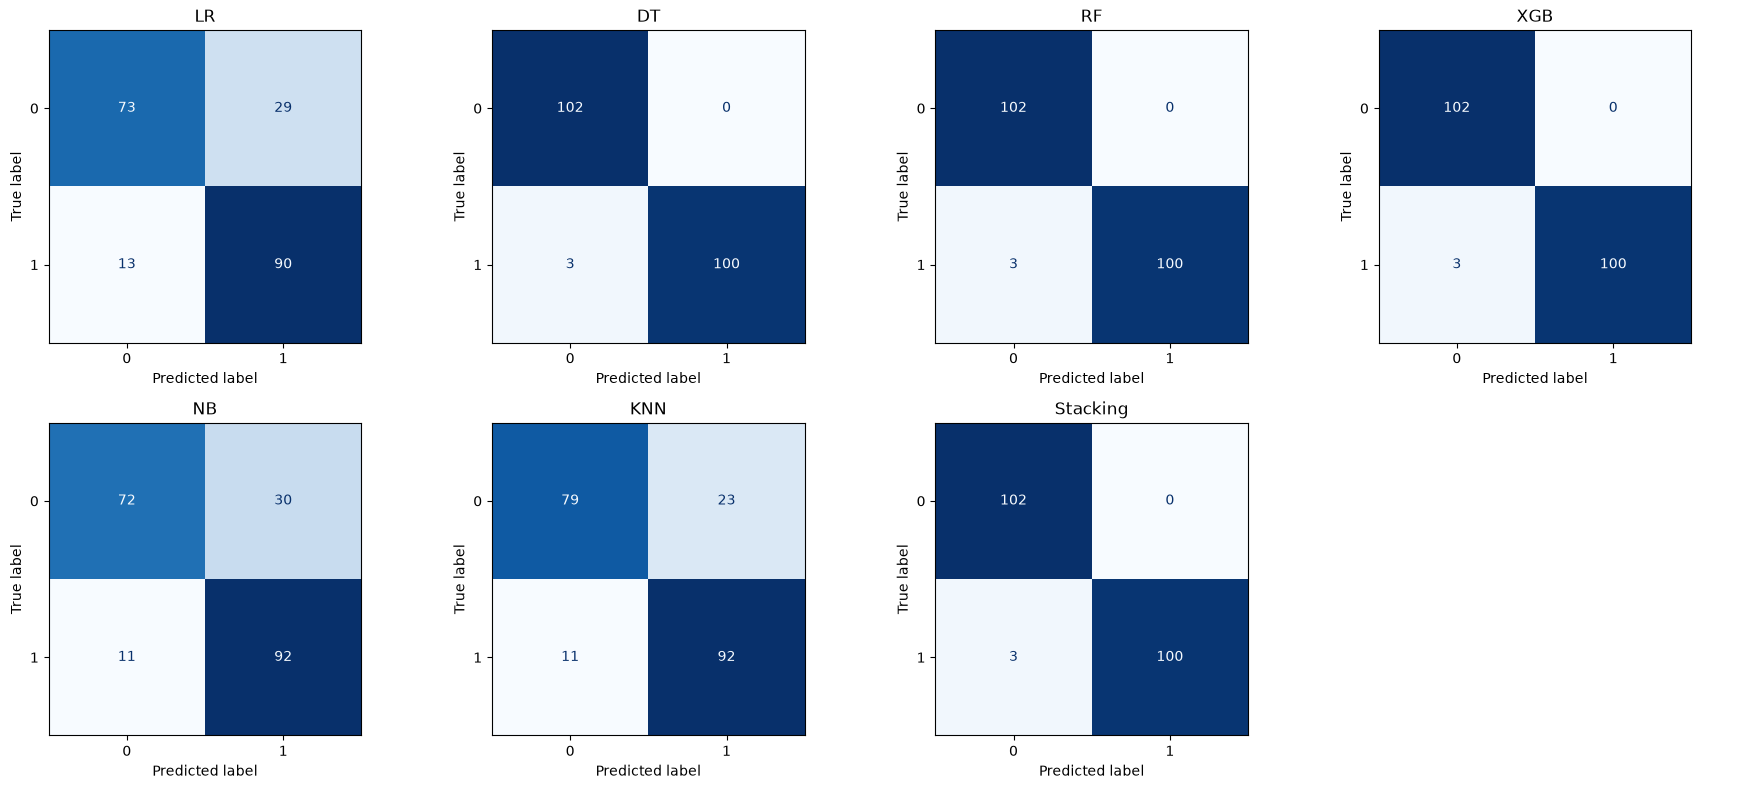

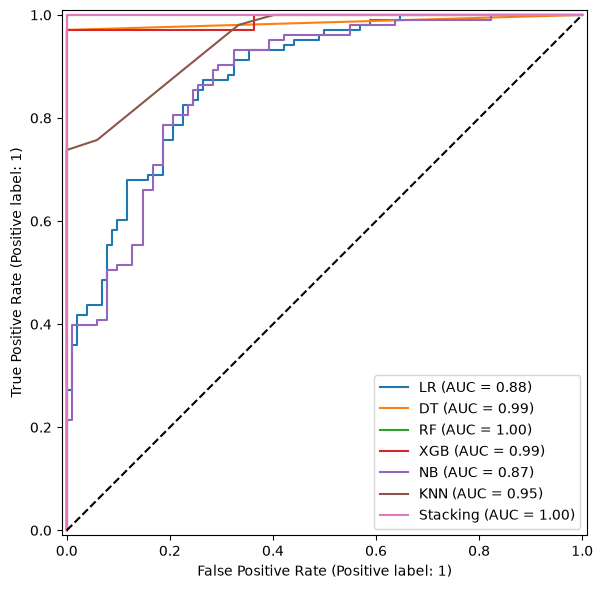

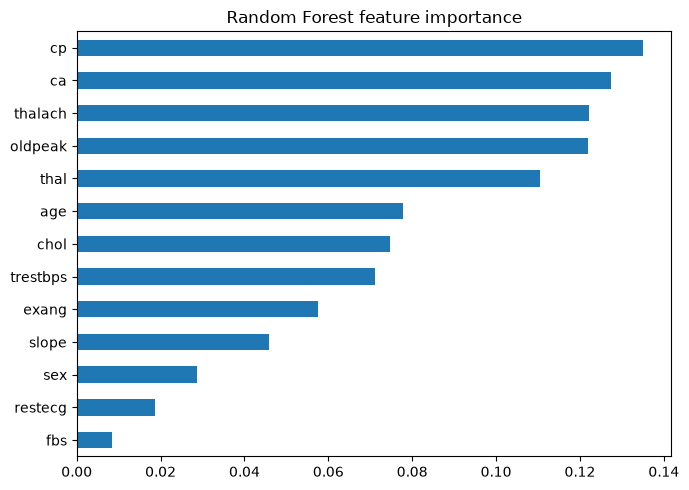

Seen: 199, Unseen: 6
LR        seen acc: 0.789 | unseen acc: 1.000
DT        seen acc: 1.000 | unseen acc: 0.500
RF        seen acc: 1.000 | unseen acc: 0.500
XGB       seen acc: 1.000 | unseen acc: 0.500
NB        seen acc: 0.794 | unseen acc: 1.000
KNN       seen acc: 0.829 | unseen acc: 1.000
Stacking  seen acc: 1.000 | unseen acc: 0.500


In [6]:
#Refit on the seed-42 split (the previous cell left models fitted on the last seed)
for m in models.values():
    m.fit(X_train, y_train)

#Confusion matrices
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, (name, m) in zip(axes.ravel(), models.items()):
    ConfusionMatrixDisplay.from_estimator(m, X_test, y_test, ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
axes.ravel()[-1].axis("off")
plt.tight_layout(); plt.savefig("fig_confusion_matrices.png", dpi=200); plt.show()

#ROC curves (from probabilities)
fig, ax = plt.subplots(figsize=(7, 6))
for name, m in models.items():
    RocCurveDisplay.from_estimator(m, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], "k--")
plt.tight_layout() 
plt.savefig("fig_roc.png", dpi=200) 
plt.show()

#RF feature importance (paper Fig. 2 does not state the model; RF assumed)
imp = pd.Series(models["RF"][-1].feature_importances_, index=X.columns).sort_values()
imp.plot.barh(figsize=(7, 5), title="Random Forest feature importance")
plt.tight_layout()
plt.savefig("fig_feature_importance.png", dpi=200) 
plt.show()

#Accuracy on test rows seen vs unseen in training
seen = np.array([tuple(r) in train_rows for r in df.loc[X_test.index].values])
print(f"Seen: {seen.sum()}, Unseen: {(~seen).sum()}")
for name, m in models.items():
    pred = m.predict(X_test)
    print(f"{name:9s} seen acc: {(pred[seen] == y_test[seen]).mean():.3f} | "
          f"unseen acc: {(pred[~seen] == y_test[~seen]).mean():.3f}")

## Part 2 – Proposed leakage-free, duplicate-aware stacking pipeline
1. Remove duplicate records before any split (302 unique patients).
2. Recode `ca = 4` and `thal = 0` as missing; impute inside each fold.
3. One-hot encode nominal features and scale numeric features inside the pipeline.
4. Regularised stacking: fully grown DT removed, base-learner settings fixed in advance (not tuned), meta-learner trained on out-of-fold probabilities.
5. Evaluate all models on identical folds of repeated stratified 5-fold CV (5 repeats), with Wilcoxon and Nadeau–Bengio corrected t-tests.

In [7]:
#Deduplicate; recode hidden missing values
data = df.drop_duplicates().reset_index(drop=True)
Xd_raw, yd = data.drop(columns="target"), data["target"]          
Xd = Xd_raw.copy()
Xd.loc[Xd["ca"] == 4, "ca"] = np.nan
Xd.loc[Xd["thal"] == 0, "thal"] = np.nan
print("After dedup:", data.shape, "| classes:", yd.value_counts().to_dict(),
      "| missing:", Xd.isna().sum()[lambda s: s > 0].to_dict())

#Leakage-free preprocessing (fitted inside each fold)
nominal = ["cp", "restecg", "slope", "thal"]
numeric = [c for c in Xd.columns if c not in nominal]
prep = ColumnTransformer([
    ("num", make_pipeline(IterativeImputer(random_state=SEED), StandardScaler()), numeric),
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                          OneHotEncoder(handle_unknown="ignore")), nominal),
])

#Regularised base learners (fixed a priori for n ~ 240 training rows, not tuned)
def proposed_base():
    return [
        ("LR", LogisticRegression(C=0.5, max_iter=1000)),
        ("RF", RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=SEED)),
        ("XGB", XGBClassifier(n_estimators=200, max_depth=2, learning_rate=0.05,
                              subsample=0.8, random_state=SEED, eval_metric="logloss")),
        ("KNN", KNeighborsClassifier(n_neighbors=15)),
        ("NB", GaussianNB()),
    ]

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
paper_stack = lambda: StackingClassifier(list(base_models().items()),
                                         final_estimator=LogisticRegression(), cv=5)

configs = {f"Paper {n}": (make_pipeline(StandardScaler(), m), Xd_raw)
           for n, m in base_models().items()}
configs["Paper Stacking"] = (make_pipeline(StandardScaler(), paper_stack()), Xd_raw)
configs["Ablation: new prep + paper stacking"] = (
    Pipeline([("prep", prep), ("clf", paper_stack())]), Xd)
configs["Proposed"] = (Pipeline([("prep", prep), ("clf", StackingClassifier(
    proposed_base(), final_estimator=LogisticRegression(),
    cv=inner_cv, stack_method="predict_proba"))]), Xd)

#Repeated stratified CV, identical folds for every model
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEED)
scoring = {"Accuracy": "accuracy", "Precision": "precision",
           "Recall": "recall", "F1": "f1", "AUC": "roc_auc"}

scores = {}
for name, (model, X_in) in configs.items():
    res = cross_validate(model, X_in, yd, cv=cv, scoring=scoring, n_jobs=-1)
    scores[name] = {m: res[f"test_{m}"] for m in scoring}

part2 = pd.DataFrame({n: {m: f"{v.mean():.4f} ± {v.std():.4f}" for m, v in s.items()}
                      for n, s in scores.items()}).T
display(part2)

#Significance: Wilcoxon + Nadeau-Bengio corrected resampled t-test
def corrected_ttest(a, b, test_train_ratio=0.25):
    d = a - b
    k = len(d)
    t_stat = d.mean() / np.sqrt((1 / k + test_train_ratio) * d.var(ddof=1))
    return t_stat, 2 * t.sf(abs(t_stat), k - 1)

stats_rows = []
for ref in ["Paper Stacking", "Paper RF"]:
    for m in scoring:
        a, b = scores["Proposed"][m], scores[ref][m]
        t_stat, p_t = corrected_ttest(a, b)
        stats_rows.append({"vs": ref, "Metric": m, "Mean diff": a.mean() - b.mean(),
                           "Wilcoxon p": wilcoxon(a, b).pvalue,
                           "Corrected t p": p_t})
pd.DataFrame(stats_rows).round(4)

After dedup: (302, 14) | classes: {1: 164, 0: 138} | missing: {'ca': 4, 'thal': 2}


,Accuracy,Precision,Recall,F1,AUC
Paper LR,0.8205 ± 0.0271,0.8134 ± 0.0447,0.8767 ± 0.0677,0.8408 ± 0.0260,0.9016 ± 0.0251
Paper DT,0.7602 ± 0.0595,0.7741 ± 0.0529,0.7904 ± 0.0843,0.7803 ± 0.0589,0.7575 ± 0.0585
Paper RF,0.8245 ± 0.0338,0.8259 ± 0.0456,0.8632 ± 0.0601,0.8419 ± 0.0313,0.9018 ± 0.0294
Paper XGB,0.8019 ± 0.0494,0.8114 ± 0.0490,0.8316 ± 0.0784,0.8189 ± 0.0499,0.8781 ± 0.0313
Paper NB,0.8151 ± 0.0383,0.8224 ± 0.0450,0.8464 ± 0.0704,0.8317 ± 0.0383,0.8962 ± 0.0330
Paper KNN,0.8146 ± 0.0375,0.8096 ± 0.0492,0.8671 ± 0.0515,0.8356 ± 0.0325,0.8814 ± 0.0385
Paper Stacking,0.8298 ± 0.0357,0.8243 ± 0.0442,0.8781 ± 0.0675,0.8479 ± 0.0350,0.9027 ± 0.0321
Ablation: new prep + paper stacking,0.8271 ± 0.0318,0.8274 ± 0.0440,0.8670 ± 0.0626,0.8443 ± 0.0304,0.9036 ± 0.0272
Proposed,0.8318 ± 0.0296,0.8276 ± 0.0344,0.8766 ± 0.0766,0.8486 ± 0.0321,0.9129 ± 0.0207


,vs,Metric,Mean diff,Wilcoxon p,Corrected t p
0,Paper Stacking,Accuracy,0.0020,0.9702,0.9135
1,Paper Stacking,Precision,0.0034,0.8077,0.8527
2,Paper Stacking,Recall,-0.0015,0.5981,0.9540
3,Paper Stacking,F1,0.0007,0.9090,0.9693
4,Paper Stacking,AUC,0.0102,0.0370,0.3827
5,Paper RF,Accuracy,0.0073,0.1710,0.6867
6,Paper RF,Precision,0.0017,0.8086,0.9206
7,Paper RF,Recall,0.0134,0.1289,0.5758
8,Paper RF,F1,0.0066,0.2940,0.6867
9,Paper RF,AUC,0.0111,0.0031,0.2298


## Part 2 – Figures

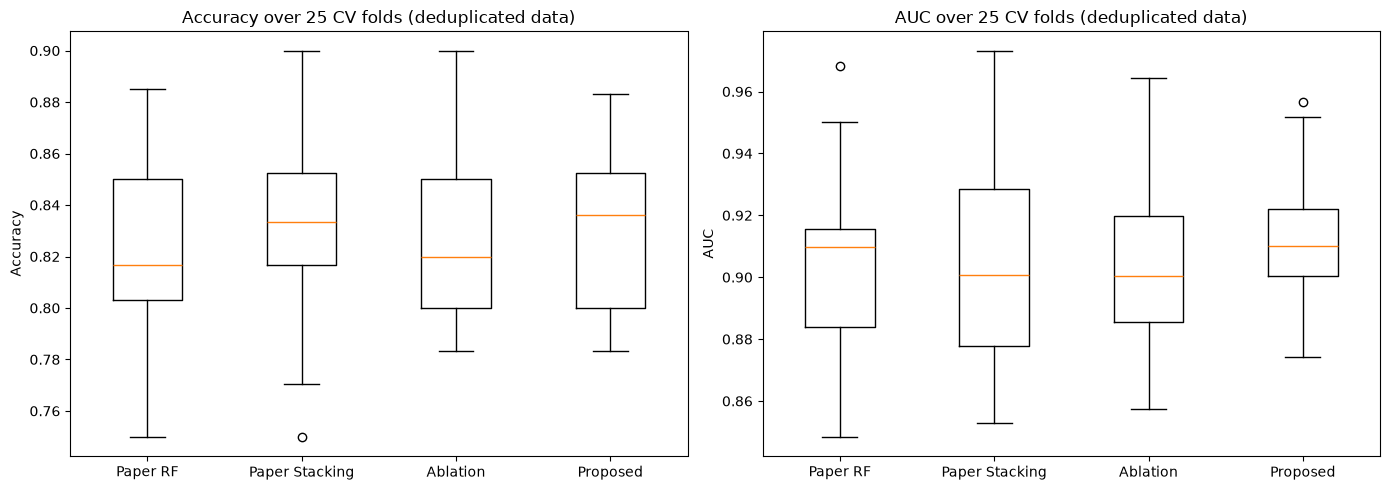

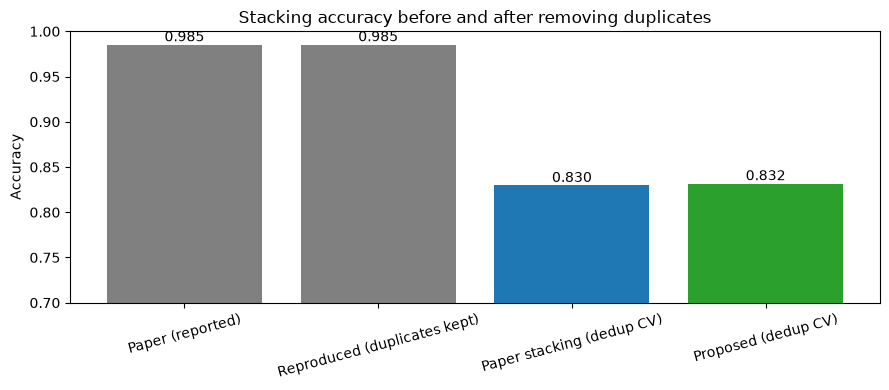

In [8]:
#Fold-level distributions on deduplicated data
names = ["Paper RF", "Paper Stacking", "Ablation: new prep + paper stacking", "Proposed"]
labels = ["Paper RF", "Paper Stacking", "Ablation", "Proposed"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, m in zip(axes, ["Accuracy", "AUC"]):
    ax.boxplot([scores[n][m] for n in names])
    ax.set_xticklabels(labels)
    ax.set_title(f"{m} over 25 CV folds (deduplicated data)")
    ax.set_ylabel(m)
plt.tight_layout() 
plt.savefig("fig_part2_boxplots.png", dpi=200) 
plt.show()

#Headline accuracy: reported vs reproduced vs deduplicated
vals = {"Paper (reported)": 0.9853,
        "Reproduced (duplicates kept)": res_df.loc["Stacking", "Accuracy"],
        "Paper stacking (dedup CV)": scores["Paper Stacking"]["Accuracy"].mean(),
        "Proposed (dedup CV)": scores["Proposed"]["Accuracy"].mean()}
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(vals.keys(), vals.values(), color=["grey", "grey", "tab:blue", "tab:green"])
ax.bar_label(bars, fmt="%.3f"); ax.set_ylim(0.7, 1.0); ax.set_ylabel("Accuracy")
ax.set_title("Stacking accuracy before and after removing duplicates")
plt.xticks(rotation=15) 
plt.tight_layout()
plt.savefig("fig_headline_accuracy.png", dpi=200) 
plt.show()

## Environment

In [9]:
import sklearn, xgboost, scipy, matplotlib
for lib in [pd, np, sklearn, xgboost, scipy, matplotlib]:
    print(f"{lib.__name__}=={lib.__version__}")

pandas==3.0.3
numpy==2.4.6
sklearn==1.9.0
xgboost==3.4.1
scipy==1.18.0
matplotlib==3.11.0
